In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

In [2]:
X_train = np.load('../artifacts/X_train_preprocessed.npy')
X_test = np.load('../artifacts/X_test_preprocessed.npy')
y_train = np.load('../artifacts/y_train.npy')
y_test = np.load('../artifacts/y_test.npy')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля оттока train: {y_train.mean():.2%}, test: {y_test.mean():.2%}")

Train: (5634, 38), Test: (1409, 38)
Доля оттока train: 26.54%, test: 26.54%


In [7]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("Логистическая регрессия")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"F1: {f1_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

Логистическая регрессия
AUC-ROC: 0.8428
F1: 0.5872
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [4]:
# Попробуем несколько архитектур и выберем лучшую по кросс-валидации
architectures = [
    (32,),
    (64,),
    (64, 32),
    (128, 64),
    (64, 32, 16)
]

best_auc = 0
best_mlp = None
best_arch = None

for arch in architectures:
    mlp = MLPClassifier(hidden_layer_sizes=arch, activation='relu',
                        solver='adam', alpha=0.0001, batch_size='auto',
                        max_iter=500, random_state=42, verbose=False)
    scores = cross_val_score(mlp, X_train, y_train, cv=3, scoring='roc_auc')
    mean_auc = scores.mean()
    print(f"Архитектура {arch}: средний AUC-ROC = {mean_auc:.4f}")
    if mean_auc > best_auc:
        best_auc = mean_auc
        best_arch = arch

print(f"\nЛучшая архитектура: {best_arch} со средним AUC-ROC = {best_auc:.4f}")

Архитектура (32,): средний AUC-ROC = 0.8141
Архитектура (64,): средний AUC-ROC = 0.8024
Архитектура (64, 32): средний AUC-ROC = 0.7843
Архитектура (128, 64): средний AUC-ROC = 0.7860
Архитектура (64, 32, 16): средний AUC-ROC = 0.7746

Лучшая архитектура: (32,) со средним AUC-ROC = 0.8141


In [6]:
mlp_final = MLPClassifier(hidden_layer_sizes=best_arch, activation='relu',
                          solver='adam', alpha=0.0001, batch_size='auto',
                          max_iter=500, random_state=42, verbose=True)
mlp_final.fit(X_train, y_train)

y_pred_mlp = mlp_final.predict(X_test)
y_proba_mlp = mlp_final.predict_proba(X_test)[:, 1]

print("\nMLPClassifier (нейросетевой базлайн)")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(f"F1: {f1_score(y_test, y_pred_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))

Iteration 1, loss = 0.54263958
Iteration 2, loss = 0.47050186
Iteration 3, loss = 0.44674876
Iteration 4, loss = 0.43540089
Iteration 5, loss = 0.42828528
Iteration 6, loss = 0.42320796
Iteration 7, loss = 0.42017569
Iteration 8, loss = 0.41780486
Iteration 9, loss = 0.41599750
Iteration 10, loss = 0.41426194
Iteration 11, loss = 0.41324012
Iteration 12, loss = 0.41323990
Iteration 13, loss = 0.41167085
Iteration 14, loss = 0.41029700
Iteration 15, loss = 0.40946831
Iteration 16, loss = 0.40913990
Iteration 17, loss = 0.40841829
Iteration 18, loss = 0.40773638
Iteration 19, loss = 0.40683983
Iteration 20, loss = 0.40655210
Iteration 21, loss = 0.40664566
Iteration 22, loss = 0.40548280
Iteration 23, loss = 0.40512025
Iteration 24, loss = 0.40512944
Iteration 25, loss = 0.40445359
Iteration 26, loss = 0.40371094
Iteration 27, loss = 0.40357657
Iteration 28, loss = 0.40315025
Iteration 29, loss = 0.40301989
Iteration 30, loss = 0.40300262
Iteration 31, loss = 0.40257926
Iteration 32, los

In [8]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'AUC-ROC': roc_auc_score(y_test, y_proba_lr),
     'F1': f1_score(y_test, y_pred_lr), 'Accuracy': accuracy_score(y_test, y_pred_lr)},
    {'Model': f'MLP {best_arch}', 'AUC-ROC': roc_auc_score(y_test, y_proba_mlp),
     'F1': f1_score(y_test, y_pred_mlp), 'Accuracy': accuracy_score(y_test, y_pred_mlp)}
])
print("Сравнение моделей на тестовой выборке:")
print(results.round(4))

Сравнение моделей на тестовой выборке:
                 Model  AUC-ROC      F1  Accuracy
0  Logistic Regression   0.8428  0.5872    0.8034
1            MLP (32,)   0.8226  0.5727    0.7892


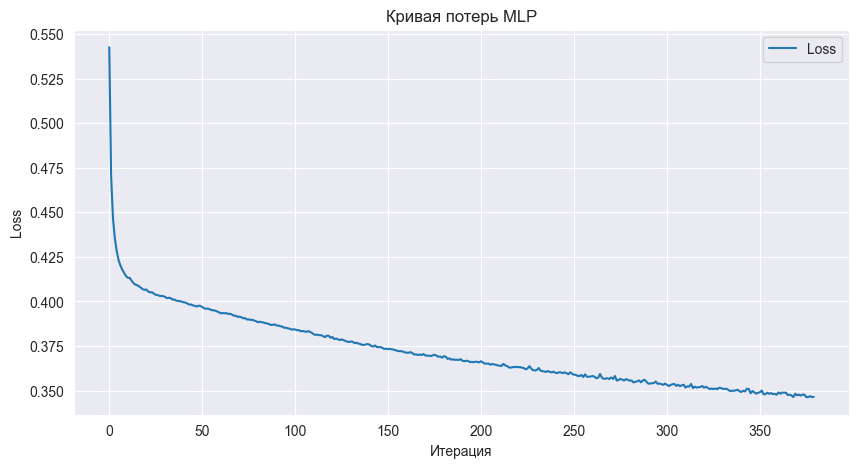

In [9]:
plt.figure(figsize=(10,5))
plt.plot(mlp_final.loss_curve_, label='Loss')
plt.title('Кривая потерь MLP')
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
if roc_auc_score(y_test, y_proba_mlp) > roc_auc_score(y_test, y_proba_lr):
    joblib.dump(mlp_final, '../artifacts/mlp_model.joblib')
    print("MLP модель сохранена в artifacts/mlp_model.joblib (улучшила логистическую регрессию)")
else:
    joblib.dump(mlp_final, '../artifacts/mlp_model.joblib')
    print("MLP модель сохранена, но не превзошла логистическую регрессию.")

MLP модель сохранена, но не превзошла логистическую регрессию.


In [13]:
print(f"Лучшая архитектура MLP: {best_arch}")
print(f"AUC-ROC MLP: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(f"AUC-ROC Logistic Regression: {roc_auc_score(y_test, y_proba_lr):.4f}")
print("Вывод: MLP не превзошёл логистическую регрессию.")

Лучшая архитектура MLP: (32,)
AUC-ROC MLP: 0.8226
AUC-ROC Logistic Regression: 0.8428
Вывод: MLP не превзошёл логистическую регрессию.
